   max_depth  Training Accuracy  Testing Accuracy
0        1.0                1.0              0.75
1        2.0                1.0              0.75
2        3.0                1.0              0.75
3        5.0                1.0              0.75
4        NaN                1.0              0.75


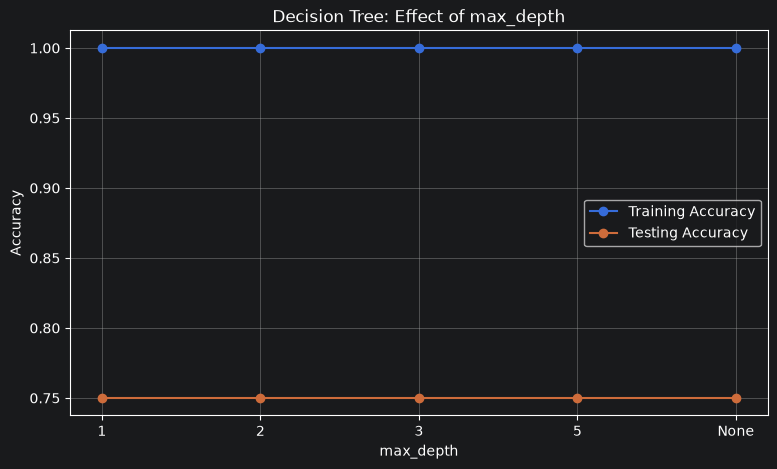

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from SCIKIT.Lesson14Classifiacationmatrics import Y_train

# -----------------------------
# 1. Create dataset
# -----------------------------

data = {
    "Study_Hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "Attendance": [50, 55, 60, 65, 68, 72, 78, 82, 86, 90, 94, 96,
                   88, 92, 97, 99],
    "Passed": [
        "No", "No", "No", "No", "No", "Yes", "Yes", "Yes",
        "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)

X = df[["Study_Hours", "Attendance"]]
y = df["Passed"]


# -----------------------------
# 2. Train/test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


# -----------------------------
# 3. Compare different depths
# -----------------------------

depths = [1, 2, 3, 5, None]

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)


# -----------------------------
# 4. Display results
# -----------------------------

results = pd.DataFrame({
    "max_depth": depths,
    "Training Accuracy": train_scores,
    "Testing Accuracy": test_scores
})

print(results)


# -----------------------------
# 5. Plot results
# -----------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    range(len(depths)),
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(len(depths)),
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xticks(
    range(len(depths)),
    ["1", "2", "3", "5", "None"]
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Effect of max_depth")
plt.legend()
plt.grid(True)

plt.show()

   Study_Hours  Attendance Passed
0     6.243562   81.889703    Yes
1    14.310000   72.165782    Yes
2    11.247915   58.571657    Yes
3     9.381219   88.827701    Yes
4     3.184261   81.083870    Yes

Dataset shape: (500, 3)

Results:
    max_depth  Training Accuracy  Testing Accuracy
0           1           0.824000             0.808
1           2           0.906667             0.864
2           3           0.920000             0.904
3           4           0.925333             0.872
4           5           0.949333             0.856
5           6           0.965333             0.840
6           7           0.976000             0.848
7           8           0.986667             0.808
8           9           0.994667             0.816
9          10           1.000000             0.832
10         11           1.000000             0.832
11         12           1.000000             0.832
12         13           1.000000             0.832
13         14           1.000000             0.

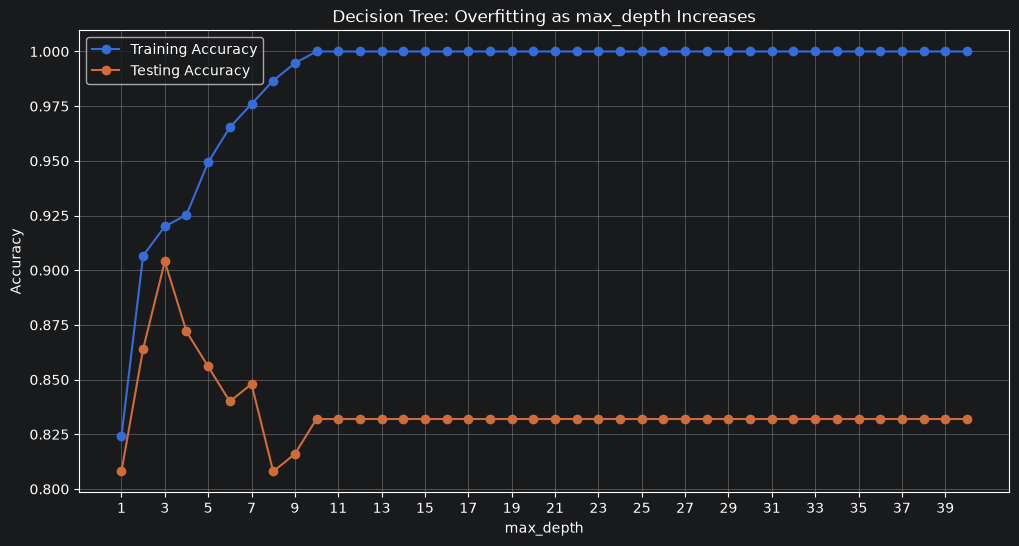

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# ============================================
# 1. CREATE A LARGER DATASET
# ============================================

np.random.seed(42)

n_samples = 500

study_hours = np.random.uniform(1, 15, n_samples)
attendance = np.random.uniform(40, 100, n_samples)

# Create the real pattern
score = (
    study_hours * 5
    + attendance * 0.5
    + np.random.normal(0, 12, n_samples)  # noise
)

passed = np.where(score >= 55, "Yes", "No")

df = pd.DataFrame({
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Passed": passed
})

print(df.head())
print("\nDataset shape:", df.shape)


# ============================================
# 2. FEATURES AND TARGET
# ============================================

X = df[["Study_Hours", "Attendance"]]
y = df["Passed"]


# ============================================
# 3. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# ============================================
# 4. TEST max_depth FROM 1 TO 40
# ============================================

depths = list(range(1, 41))

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Training prediction
    train_pred = model.predict(X_train)

    # Testing prediction
    test_pred = model.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)


# ============================================
# 5. CREATE RESULTS TABLE
# ============================================

results = pd.DataFrame({
    "max_depth": depths,
    "Training Accuracy": train_scores,
    "Testing Accuracy": test_scores
})

print("\nResults:")
print(results)


# ============================================
# 6. FIND BEST TESTING DEPTH
# ============================================

best_index = np.argmax(test_scores)

best_depth = depths[best_index]
best_test_accuracy = test_scores[best_index]

print("\nBest max_depth:", best_depth)
print("Best testing accuracy:", best_test_accuracy)


# ============================================
# 7. PLOT TRAINING VS TESTING ACCURACY
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Overfitting as max_depth Increases")

plt.xticks(range(1, 41, 2))

plt.legend()
plt.grid(True)

plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# -----------------------------
# 1. Create dataset
# -----------------------------

data = {
    "Study_Hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "Attendance": [50, 55, 60, 65, 68, 72, 78, 82, 86, 90, 94, 96,
                   88, 92, 97, 99],
    "Passed": [
        "No", "No", "No", "No", "No", "Yes", "Yes", "Yes",
        "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)

X = df[["Study_Hours", "Attendance"]]
Y = df["Passed"]



In [4]:
X_train,X_test,Y_train,Y_test=train_test_split(


    X,
    Y,
    test_size=0.25,
    random_state=42,
)
depths=list(np.arange(1,30))


In [8]:
test_score =[]
train_score=[]



results:
   max_depth  Training Accuracy  Testing Accuracy
0        1.0                1.0              0.75
1        2.0                1.0              0.75
2        3.0                1.0              0.75
3        5.0                1.0              0.75
4        NaN                1.0              0.75


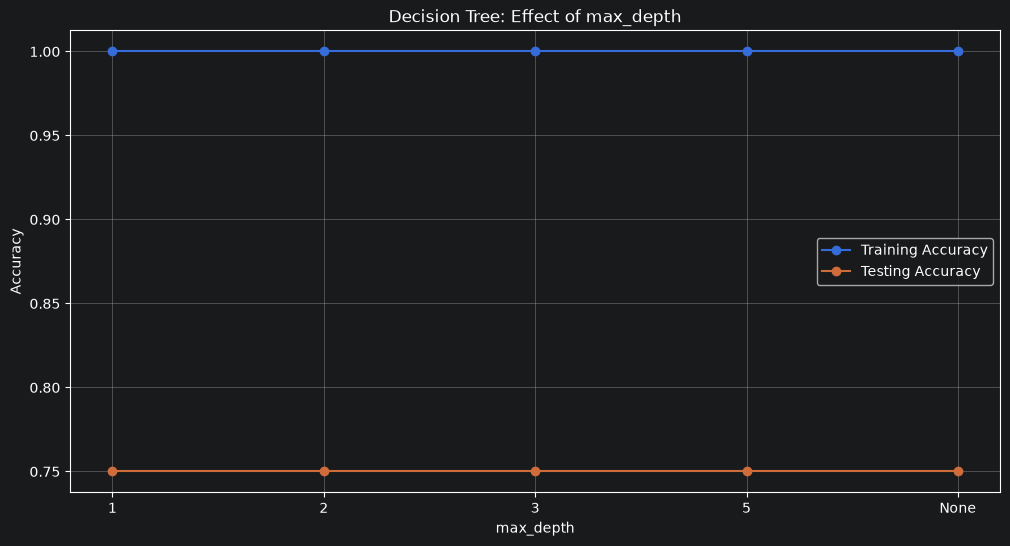

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

train_scores = []
test_scores = []

depths = [1, 2, 3, 5, None]

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, Y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(Y_train, train_pred)
    test_accuracy = accuracy_score(Y_test, test_pred)

    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)

# Build results DataFrame AFTER the loop
results = pd.DataFrame({
    "max_depth": depths,
    "Training Accuracy": train_scores,
    "Testing Accuracy": test_scores
})

print("results:")
print(results)

# Plot accuracies
plt.figure(figsize=(12, 6))
plt.plot(range(len(depths)), train_scores, marker="o", label="Training Accuracy")
plt.plot(range(len(depths)), test_scores, marker="o", label="Testing Accuracy")

plt.xticks(range(len(depths)), ["1", "2", "3", "5", "None"])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Effect of max_depth")
plt.legend()
plt.grid(True)
plt.show()


MAX_DEPTH
    max_depth  Train Accuracy  Test Accuracy
0           1        0.824000          0.808
1           2        0.906667          0.864
2           3        0.920000          0.904
3           4        0.925333          0.872
4           5        0.949333          0.856
5           6        0.965333          0.840
6           7        0.976000          0.848
7           8        0.986667          0.808
8           9        0.994667          0.816
9          10        1.000000          0.832
10         11        1.000000          0.832
11         12        1.000000          0.832
12         13        1.000000          0.832
13         14        1.000000          0.832
14         15        1.000000          0.832
15         16        1.000000          0.832
16         17        1.000000          0.832
17         18        1.000000          0.832
18         19        1.000000          0.832
19         20        1.000000          0.832

MIN_SAMPLES_SPLIT
   min_samples_split  Trai

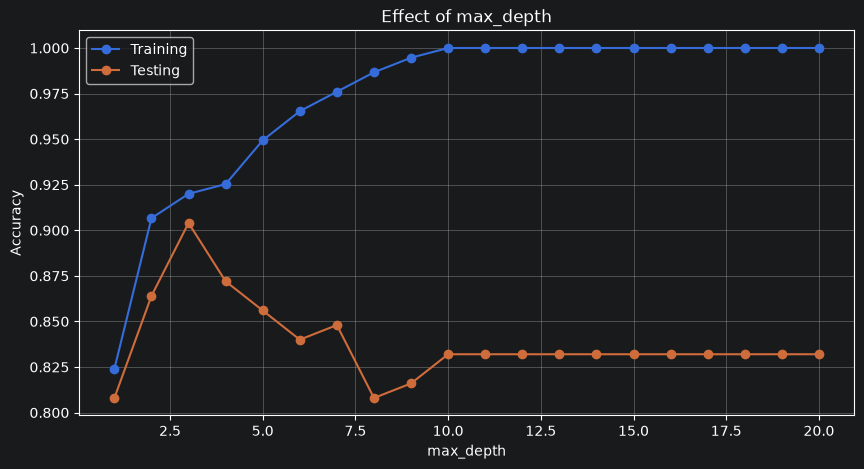

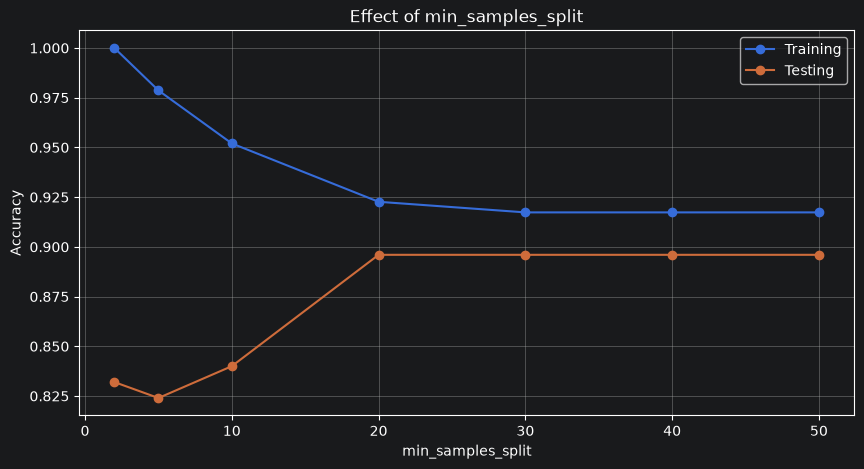

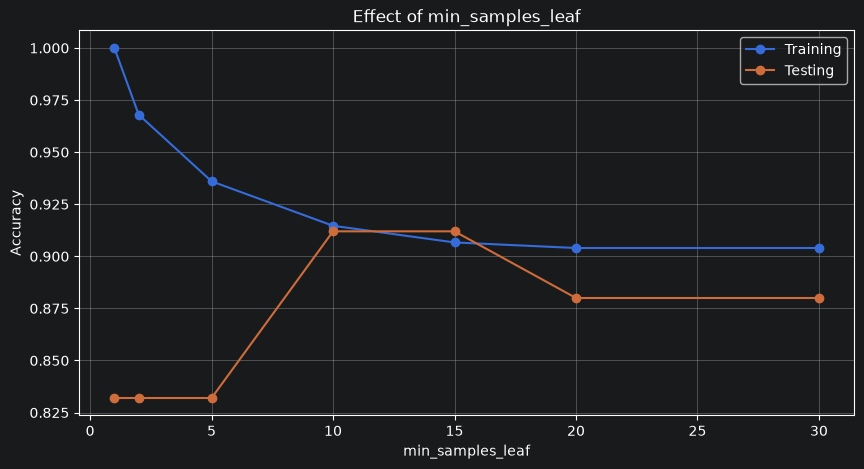

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# ============================================
# 1. CREATE DATASET
# ============================================

np.random.seed(42)

n_samples = 500

study_hours = np.random.uniform(1, 15, n_samples)
attendance = np.random.uniform(40, 100, n_samples)

score = (
    study_hours * 5
    + attendance * 0.5
    + np.random.normal(0, 12, n_samples)
)

passed = np.where(score >= 55, "Yes", "No")

df = pd.DataFrame({
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Passed": passed
})

X = df[["Study_Hours", "Attendance"]]
y = df["Passed"]


# ============================================
# 2. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# ============================================
# 3. max_depth COMPARISON
# ============================================

depths = range(1, 21)

depth_train = []
depth_test = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    depth_train.append(
        accuracy_score(
            y_train,
            model.predict(X_train)
        )
    )

    depth_test.append(
        accuracy_score(
            y_test,
            model.predict(X_test)
        )
    )


# ============================================
# 4. min_samples_split COMPARISON
# ============================================

split_values = [2, 5, 10, 20, 30, 40, 50]

split_train = []
split_test = []

for value in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=value,
        random_state=42
    )

    model.fit(X_train, y_train)

    split_train.append(
        accuracy_score(
            y_train,
            model.predict(X_train)
        )
    )

    split_test.append(
        accuracy_score(
            y_test,
            model.predict(X_test)
        )
    )


# ============================================
# 5. min_samples_leaf COMPARISON
# ============================================

leaf_values = [1, 2, 5, 10, 15, 20, 30]

leaf_train = []
leaf_test = []

for value in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=value,
        random_state=42
    )

    model.fit(X_train, y_train)

    leaf_train.append(
        accuracy_score(
            y_train,
            model.predict(X_train)
        )
    )

    leaf_test.append(
        accuracy_score(
            y_test,
            model.predict(X_test)
        )
    )


# ============================================
# 6. DISPLAY RESULTS
# ============================================

print("MAX_DEPTH")
print(
    pd.DataFrame({
        "max_depth": list(depths),
        "Train Accuracy": depth_train,
        "Test Accuracy": depth_test
    })
)

print("\nMIN_SAMPLES_SPLIT")
print(
    pd.DataFrame({
        "min_samples_split": split_values,
        "Train Accuracy": split_train,
        "Test Accuracy": split_test
    })
)

print("\nMIN_SAMPLES_LEAF")
print(
    pd.DataFrame({
        "min_samples_leaf": leaf_values,
        "Train Accuracy": leaf_train,
        "Test Accuracy": leaf_test
    })
)


# ============================================
# 7. PLOT max_depth
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    list(depths),
    depth_train,
    marker="o",
    label="Training"
)

plt.plot(
    list(depths),
    depth_test,
    marker="o",
    label="Testing"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth")
plt.legend()
plt.grid(True)
plt.show()


# ============================================
# 8. PLOT min_samples_split
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    split_values,
    split_train,
    marker="o",
    label="Training"
)

plt.plot(
    split_values,
    split_test,
    marker="o",
    label="Testing"
)

plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.title("Effect of min_samples_split")
plt.legend()
plt.grid(True)
plt.show()


# ============================================
# 9. PLOT min_samples_leaf
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    leaf_values,
    leaf_train,
    marker="o",
    label="Training"
)

plt.plot(
    leaf_values,
    leaf_test,
    marker="o",
    label="Testing"
)

plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Effect of min_samples_leaf")
plt.legend()
plt.grid(True)
plt.show()